In [2]:
import pandas as pd                                        # DataFrame operations
import numpy as np                                         # numerical operations
from sklearn.feature_extraction.text import CountVectorizer      # builds DTM from text
from sklearn.feature_extraction.text import TfidfVectorizer      # builds TF-IDF matrix
from sklearn.decomposition import TruncatedSVD             # dimensionality reduction (LSA)
from sklearn.preprocessing import Normalizer              # L2 normalize SVD output
from sklearn.decomposition import LatentDirichletAllocation  # topic modeling - LDA (sklearn)
from sklearn.mixture import GaussianMixture                  # clustering - Mixture Model
import matplotlib.pyplot as plt                            # plotting
import seaborn as sns                                      # prettier plots
import scipy.sparse                                        # for inspecting sparse matrices

Load clean data

In [3]:
# Load the preprocessed sessions DataFrame from Phase 2
df = pd.read_csv("../data/processed/sessions_clean.csv")  # read clean data

print(f"Loaded {len(df)} sessions")                        # confirm row count
print(f"Columns: {list(df.columns)}")                      # show available columns
print(df[['child_id', 'age_months', 'text_clean']].head(3))  # preview

Loaded 214 sessions
Columns: ['file_id', 'child_id', 'age_months', 'n_utterances', 'n_tokens', 'mlu', 'ttr', 'text', 'text_clean', 'text_no_lemma', 'text_with_stops', 'n_raw', 'n_clean', 'n_with_stops', 'n_no_lemma']
  child_id  age_months                                         text_clean
0     Adam       27.13  play checker big drum big drum big drum big dr...
1     Adam       27.60  okay suitcase suitcase spaghetti monroe suitca...
2     Adam       28.10  yeah train water water right water jack jill c...


Build the DTM with CountVectorizer

In [4]:
# Initialize CountVectorizer with frequency cutoffs
# min_df=2: ignore words that appear in fewer than 2 sessions (too rare, just noise)
# max_df=0.95: ignore words that appear in more than 95% of sessions (too common, no signal)
vectorizer_counts = CountVectorizer(
    ngram_range=(1, 2),                                      # unigrams and bigrams
    min_df=2,                                              # minimum document frequency
    max_df=0.95                                            # maximum document frequency
)

# fit_transform on text_clean:
# fit   = learn the vocabulary from all sessions
# transform = convert each session into a vector of word counts
DTM = vectorizer_counts.fit_transform(df['text_clean'])    # returns sparse matrix

# Inspect the DTM shape: (n_sessions, n_vocabulary_terms)
print(f"DTM shape: {DTM.shape}")                           # should be (214, ~vocab_size)
print(f"Vocabulary size: {len(vectorizer_counts.vocabulary_)}")  # unique words kept

# Show first 10 words in the vocabulary (alphabetically sorted)
vocab = vectorizer_counts.get_feature_names_out()          # array of all vocabulary words
print(f"\nFirst 10 vocab words: {vocab[:10]}")             # preview vocabulary
print(f"Last 10 vocab words:  {vocab[-10:]}")              # preview end of vocabulary

DTM shape: (214, 17196)
Vocabulary size: 17196

First 10 vocab words: ['abc' 'abc tell' 'accident' 'accident accident' 'accident put'
 'accident yeah' 'ache' 'across' 'across street' 'act']
Last 10 vocab words:  ['zero one' 'zero zero' 'zip' 'zip zip' 'zipper' 'zipper zipper' 'zoo'
 'zoo yeah' 'zoo zoo' 'zoom']


Understand DTM Sparsity

In [5]:
# A DTM is almost always a SPARSE matrix — most sessions don't use most words
# Sparsity = fraction of cells that are zero
total_cells = DTM.shape[0] * DTM.shape[1]                 # total number of cells
non_zero    = DTM.nnz                                      # number of non-zero cells
sparsity    = 1 - (non_zero / total_cells)                 # fraction that are zero

print(f"Total cells:     {total_cells:,}")                 # rows × columns
print(f"Non-zero cells:  {non_zero:,}")                    # actual word counts stored
print(f"Sparsity:        {sparsity:.1%}")                  # expect >90% sparse

Total cells:     3,679,944
Non-zero cells:  95,940
Sparsity:        97.4%


Effect of min_df Cutoff

min_df | Vocabulary Size
-------|----------------
    1  |  70,121
    2  |  17,196
    5  |  4,214
   10  |  1,714


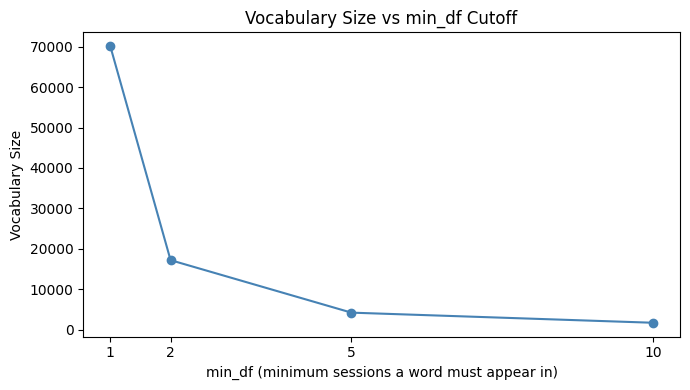

In [6]:
# Test 3 different min_df values to show the tradeoff
cutoffs   = [1, 2, 5, 10]                                  # different minimum frequencies
vocab_sizes = []                                           # store resulting vocab sizes

for cutoff in cutoffs:                                     # loop over each cutoff value
    vec = CountVectorizer(ngram_range=(1, 2),min_df=cutoff, max_df=0.95)      # build vectorizer with this cutoff
    dtm = vec.fit_transform(df['text_clean'])              # fit and transform
    vocab_sizes.append(len(vec.vocabulary_))               # record vocabulary size

# Print the tradeoff table
print("min_df | Vocabulary Size")
print("-------|----------------")
for c, v in zip(cutoffs, vocab_sizes):                     # loop and print each row
    print(f"  {c:3d}  |  {v:,}")

# Plot the tradeoff
plt.figure(figsize=(7, 4))                                 # figure size
plt.plot(cutoffs, vocab_sizes, marker='o', color='steelblue')  # line + dot per cutoff
plt.xlabel('min_df (minimum sessions a word must appear in)')  # x axis
plt.ylabel('Vocabulary Size')                              # y axis
plt.title('Vocabulary Size vs min_df Cutoff')             # title
plt.xticks(cutoffs)                                        # show all cutoff values on x axis
plt.tight_layout()                                         # clean layout
plt.savefig('../figures/mindf_vocabulary_tradeoff.png', dpi=150, bbox_inches='tight')  # save
plt.show()                                                 # display

Build TF-IDF Matrix

In [7]:
# TfidfVectorizer applies TF-IDF weighting directly
# sublinear_tf=True: use log(1+tf) instead of raw tf (dampens effect of very frequent words)
vectorizer_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),                                      # unigrams and bigrams
    min_df=2,                                              # same cutoffs as CountVectorizer
    max_df=0.95,                                           # for fair comparison
    sublinear_tf=True                                      # log normalization of term freq
)

# fit_transform: learn vocabulary AND compute TF-IDF weights in one step
TFIDF = vectorizer_tfidf.fit_transform(df['text_clean'])  # returns sparse matrix

print(f"TF-IDF matrix shape: {TFIDF.shape}")              # same shape as DTM
print(f"Vocabulary size: {len(vectorizer_tfidf.vocabulary_)}")  # should match DTM vocab

TF-IDF matrix shape: (214, 17196)
Vocabulary size: 17196


Compare DTM vs TF-IDF for One Session

In [8]:
# Get vocabulary for reference
vocab_tfidf = vectorizer_tfidf.get_feature_names_out()     # all vocabulary words

# Pick session 0 (Adam, ~27 months) as example
session_idx = 0                                            # index of session to inspect

# Get raw counts and TF-IDF weights for this session
counts_row = DTM[session_idx].toarray().flatten()          # convert sparse row to array
tfidf_row  = TFIDF[session_idx].toarray().flatten()        # convert sparse row to array

# Build a comparison DataFrame for the top words
comparison = pd.DataFrame({
    'word'   : vocab_tfidf,                                # vocabulary word
    'count'  : counts_row,                                 # raw count in this session
    'tfidf'  : tfidf_row                                   # TF-IDF weight in this session
})

# Show top 10 words by raw count
print("=== Top 10 words by RAW COUNT ===")
print(comparison.sort_values('count', ascending=False).head(10)[['word','count','tfidf']])

# Show top 10 words by TF-IDF weight
print("\n=== Top 10 words by TF-IDF WEIGHT ===")
print(comparison.sort_values('tfidf', ascending=False).head(10)[['word','count','tfidf']])

=== Top 10 words by RAW COUNT ===
            word  count     tfidf
8993       mommy     75  0.030565
10216       okay     66  0.039888
11          adam     64  0.069813
7143       kitty     48  0.070484
2925       daddy     45  0.036570
16441      write     40  0.039601
10805      paper     39  0.042558
1449        bozo     39  0.071175
1668   bulldozer     34  0.083705
16578       yeah     30  0.024484

=== Top 10 words by TF-IDF WEIGHT ===
                word  count     tfidf
14401         tattoo     12  0.089276
2963      daddy name     11  0.087047
12031    read shadow      9  0.086633
15213          tuffy     12  0.085279
9694      name daddy     10  0.084605
13094         shadow     30  0.084411
6962            john     13  0.083897
1668       bulldozer     34  0.083705
6414        hit ball     11  0.083150
13098  shadow shadow     13  0.081072


Apply SVD (LSA — Latent Semantic Analysis):

- SVD compresses the high-dimensional TF-IDF matrix into ~50 dimensions. This is the step that discovers latent structure without using age as input.

In [9]:
# Number of SVD components to keep
# 50 is a standard starting point — captures main variance without overfitting
N_COMPONENTS = 50                                          # number of latent dimensions

# TruncatedSVD is the sklearn implementation of LSA
# It finds the k directions of maximum variance in the TF-IDF matrix
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)  # random_state for reproducibility

# fit_transform: learn the SVD decomposition AND project data into reduced space
SVD_matrix = svd.fit_transform(TFIDF)                     # shape: (214, 50)

print(f"SVD matrix shape: {SVD_matrix.shape}")            # (n_sessions, n_components)

# How much variance does each component explain?
explained = svd.explained_variance_ratio_                 # fraction of variance per component
print(f"\nVariance explained by first 5 components:")
for i, v in enumerate(explained[:5]):                     # show first 5
    print(f"  SVD component {i+1}: {v:.3f} ({v*100:.1f}%)")

print(f"\nTotal variance explained by {N_COMPONENTS} components: {explained.sum():.3f} ({explained.sum()*100:.1f}%)")

SVD matrix shape: (214, 50)

Variance explained by first 5 components:
  SVD component 1: 0.003 (0.3%)
  SVD component 2: 0.019 (1.9%)
  SVD component 3: 0.016 (1.6%)
  SVD component 4: 0.015 (1.5%)
  SVD component 5: 0.010 (1.0%)

Total variance explained by 50 components: 0.330 (33.0%)


Normalize SVD Output

In [10]:
# After SVD, normalize each row to unit length (L2 normalization)
# This ensures cosine similarity works correctly downstream
# (as taught in Session 4 — cosine similarity requires normalized vectors)
normalizer  = Normalizer(norm='l2')                        # L2 = Euclidean normalization
SVD_normed  = normalizer.fit_transform(SVD_matrix)         # apply to all rows

print(f"Normalized SVD matrix shape: {SVD_normed.shape}")  # same shape, normalized rows

# Verify normalization: each row should now have length = 1.0
row_norms = np.linalg.norm(SVD_normed, axis=1)             # compute norm of each row
print(f"Row norm min: {row_norms.min():.4f}")              # should be 1.0
print(f"Row norm max: {row_norms.max():.4f}")              # should be 1.0

Normalized SVD matrix shape: (214, 50)
Row norm min: 1.0000
Row norm max: 1.0000


In [11]:
# Attach first 10 SVD dimensions to df for inspection
for i in range(10):                                        # loop over first 10 components
    df[f'svd_{i+1}'] = SVD_normed[:, i]                   # add svd_1 through svd_10

print("SVD columns added to DataFrame")
print(df[['child_id', 'age_months', 'svd_1', 'svd_2', 'svd_3']].head(3))  # preview

SVD columns added to DataFrame
  child_id  age_months     svd_1     svd_2     svd_3
0     Adam       27.13  0.416005  0.253657 -0.015640
1     Adam       27.60  0.368084  0.288503 -0.033092
2     Adam       28.10  0.433055  0.287423 -0.092755


In [12]:
# Save Pipeline A output — TF-IDF + SVD
# Schema: child_id | age_months | mlu | ttr | svd_1 ... svd_10
base_cols = ['child_id', 'age_months', 'mlu', 'ttr']      # metadata columns to keep
svd_cols  = [f'svd_{i+1}' for i in range(10)]             # svd dimension columns

df[base_cols + svd_cols].to_csv(                           # select only needed columns
    "../data/processed/pipeline_A_tfidf_svd.csv",          # Pipeline A output file
    index=False                                            # no row index
)

# Also save full 50-dim SVD matrix as numpy for downstream use
np.save("../data/processed/pipeline_A_SVD_matrix.npy", SVD_normed)  # full matrix

print("Pipeline A saved → pipeline_A_tfidf_svd.csv")
print(f"Shape: {df[base_cols + svd_cols].shape}")          # confirm shape


Pipeline A saved → pipeline_A_tfidf_svd.csv
Shape: (214, 14)


## Pipeline B — CountVectorizer + SVD (Baseline)
Raw word counts without TF-IDF weighting. This is our baseline — comparing A vs B shows exactly what TF-IDF contributes.


In [13]:
# Pipeline B: apply SVD directly to the raw count DTM (no TF-IDF weighting)
# DTM was already built in Cell 5 — we reuse it here
svd_B = TruncatedSVD(n_components=50, random_state=42)     # same settings as Pipeline A
SVD_B_matrix = svd_B.fit_transform(DTM)                    # fit on raw counts, not TF-IDF

normalizer_B  = Normalizer(norm='l2')                      # L2 normalizer
SVD_B_normed  = normalizer_B.fit_transform(SVD_B_matrix)   # normalize rows

# Variance explained
explained_B = svd_B.explained_variance_ratio_              # per-component variance
print(f"Pipeline B — SVD on raw counts")
print(f"Total variance explained: {explained_B.sum():.3f} ({explained_B.sum()*100:.1f}%)")
print(f"Compare to Pipeline A:    {svd.explained_variance_ratio_.sum():.3f} ({svd.explained_variance_ratio_.sum()*100:.1f}%)")

Pipeline B — SVD on raw counts
Total variance explained: 0.839 (83.9%)
Compare to Pipeline A:    0.330 (33.0%)


In [14]:
# Attach Pipeline B SVD dimensions to a clean copy
df_B = df[base_cols].copy()                                # start from metadata only
for i in range(10):                                        # add svd dimensions
    df_B[f'svd_{i+1}'] = SVD_B_normed[:, i]               # attach each component

df_B.to_csv("../data/processed/pipeline_B_counts_svd.csv", index=False)  # save
np.save("../data/processed/pipeline_B_SVD_matrix.npy", SVD_B_normed)     # full matrix

print("Pipeline B saved → pipeline_B_counts_svd.csv")
print(f"Shape: {df_B.shape}")

Pipeline B saved → pipeline_B_counts_svd.csv
Shape: (214, 14)


***One Important Result to Note***


Pipeline B variance = 83.9% vs Pipeline A = 33.0%. This is not Pipeline B being "better" — it's actually a known consequence of TF-IDF. Raw counts concentrate variance into a few very frequent words, so SVD captures it easily. TF-IDF spreads variance more evenly across the vocabulary, making the space richer but harder to compress. Pipeline A is still the better representation for our task — this difference is worth one sentence in the paper.

## Pipeline C — Dictionary Method

Two theory-driven approaches:
- C1: Custom developmental dictionary built from Brown (1973) — word categories mapped to developmental stages
- C2: MacArthur-Bates CDI — the standard vocabulary checklist used in child language research

Scoring method: normalized sum (as taught in Session 5/6) — count of matched words divided by total tokens.
This controls for session length so a longer session doesn't automatically score higher.

In [15]:
# ── CUSTOM DEVELOPMENTAL DICTIONARY ─────────────────────────────────────────
# Built from Brown (1973) Stage I-V theory of child language development
# Each category maps to a developmental milestone

dict_early_nouns = {                                       # first words children learn
    'mama','mommy','mom','dada','daddy','dad',              # caregivers — appear at ~12 months
    'ball','dog','cat','baby','cup','shoe','hat','book',    # common objects — Stage I
    'milk','juice','cookie','bread','apple','banana',       # food words — Stage I
    'car','truck','bus','boat','plane',                    # vehicles — Stage I
    'bird','fish','horse','cow','pig','duck',               # animals — Stage I
}

dict_action_words = {                                      # verbs — appear Stage I-II
    'go','come','give','want','eat','drink',                # basic action verbs
    'look','see','put','get','make','take',                 # perception/manipulation verbs
    'sit','stand','fall','run','jump','walk',               # motion verbs
    'open','close','push','pull','throw','catch',           # object manipulation
    'help','stop','wait','try',                            # social action verbs
}

dict_social_words = {                                      # pragmatic/social vocabulary
    'no','yes','yeah','hi','bye','hello',                   # basic social responses
    'please','thank','sorry','okay','uh',                   # politeness markers
    'more','again','mine','own',                           # possession/recurrence
    'there','here','this','that',                          # demonstratives
    'what','where','who','why',                            # early question words
}

dict_descriptors = {                                       # adjectives — appear Stage II-III
    'big','little','small','large','tiny',                  # size
    'hot','cold','warm','wet','dry',                       # temperature/state
    'good','bad','nice','pretty','dirty','clean',          # evaluative
    'happy','sad','mad','scared',                          # emotion words
    'red','blue','green','yellow','black','white',         # colors — Stage III+
    'fast','slow','loud','quiet',                          # manner
}

dict_late_complex = {                                      # late-emerging vocabulary
    'because','when','if','but','so','then',               # connectives — Stage IV-V
    'maybe','probably','actually','really','just',         # hedges/modifiers
    'before','after','until','while',                      # temporal connectives
    'always','never','sometimes','already',                # frequency adverbs
    'another','other','same','different',                  # comparison words
    'tell','think','know','remember','forget',             # mental state verbs — Stage V
}

# ── MacARTHUR-BATES CDI WORD LIST ────────────────────────────────────────────
# Words & Sentences form (Fenson et al. 1994) — standard 16-30 month vocabulary checklist
# This is the canonical list used in child language research
# Source: Fenson et al. (1994), MacArthur-Bates Communicative Development Inventories

cdi_words = {                                              # representative CDI word set
    # Sound effects and animal sounds
    'baa','woof','moo','quack','meow',
    # Animals
    'bear','bunny','cat','chicken','cow','dog','duck',
    'elephant','fish','frog','giraffe','horse','kitty',
    'lamb','lion','monkey','mouse','pig','puppy','tiger','zebra',
    # Vehicles
    'airplane','bike','boat','bus','car','train','truck',
    # Toys
    'ball','balloon','bat','blocks','book','bubbles','doll','game','toy',
    # Food
    'apple','banana','bread','butter','cake','candy','cereal',
    'cheese','chicken','cookie','corn','cracker','egg',
    'grape','ice','juice','meat','milk','orange','peas',
    'pizza','popcorn','potato','pretzel','raisin','sandwich',
    # Body parts
    'arm','ear','eye','face','foot','hair','hand','knee',
    'leg','mouth','nose','stomach','toe','tooth','tummy',
    # Clothing
    'boot','coat','diaper','dress','glove','hat','jacket',
    'pajama','pants','shoe','shirt','short','sock','sweater',
    # Furniture
    'bath','bathroom','bed','bedroom','bench','chair',
    'couch','crib','door','floor','lamp','table','window',
    # Outside
    'flower','garden','grass','leaf','outside','rain',
    'snow','stick','stone','sun','tree','water',
    # People
    'baby','boy','daddy','friend','girl','grandma','grandpa',
    'lady','man','mommy','people','woman',
    # Action words (CDI verbs)
    'bring','buy','catch','climb','come','cry','cut','dance',
    'draw','drink','drive','eat','fall','feed','find','finish',
    'fit','fix','get','give','go','have','help','hit',
    'hold','hug','jump','kick','kiss','like','listen','look',
    'love','make','open','pat','pick','play','pour','pull',
    'push','put','read','ride','run','say','see','show',
    'sing','sit','sleep','smell','talk','taste','throw',
    'tickle','try','turn','wait','walk','wash','watch','wipe',
    # Descriptive words (CDI adjectives)
    'allgone','big','broken','cold','dark','dirty','dry',
    'empty','fat','full','happy','hard','heavy','hot',
    'hungry','little','loud','mad','new','nice','old',
    'pretty','sad','scared','sick','silly','sleepy',
    'soft','thirsty','tired','wet','yummy',
    # Question words
    'how','what','when','where','who','why',
    # Prepositions
    'away','down','here','in','off','on','out','outside','up',
    # Social words
    'bye','hi','no','please','yes',
}

print(f"Custom dictionary sizes:")
print(f"  Early nouns:    {len(dict_early_nouns)} words")   # show category size
print(f"  Action words:   {len(dict_action_words)} words")  # show category size
print(f"  Social words:   {len(dict_social_words)} words")  # show category size
print(f"  Descriptors:    {len(dict_descriptors)} words")   # show category size
print(f"  Late complex:   {len(dict_late_complex)} words")  # show category size
print(f"\nCDI word list:    {len(cdi_words)} words")         # show CDI size

Custom dictionary sizes:
  Early nouns:    31 words
  Action words:   28 words
  Social words:   23 words
  Descriptors:    30 words
  Late complex:   28 words

CDI word list:    247 words


The custom categories are balanced (~28-31 words each) which is good — no single category dominates the scoring. CDI at 247 words is intentionally broader as it covers the full vocabulary checklist across all developmental stages.

Scoring function:

In [16]:
def score_dictionary(text, word_set):                      # takes cleaned text string + word set
    """
    Normalized sum scoring (Session 5/6):
    Count how many tokens in the session match the dictionary,
    divided by total token count — controls for session length.
    Returns a proportion between 0 and 1.
    """
    tokens = text.split()                                  # split clean text into tokens
    if len(tokens) == 0:                                   # guard against empty sessions
        return 0.0                                         # return zero for empty
    matches = sum(1 for t in tokens if t in word_set)      # count matching tokens
    return matches / len(tokens)                           # normalize by session length

# Score every session against every dictionary
df['score_early_nouns']   = df['text_clean'].apply(        # early noun score
    lambda x: score_dictionary(x, dict_early_nouns))
df['score_action_words']  = df['text_clean'].apply(        # action word score
    lambda x: score_dictionary(x, dict_action_words))
df['score_social_words']  = df['text_clean'].apply(        # social word score
    lambda x: score_dictionary(x, dict_social_words))
df['score_descriptors']   = df['text_clean'].apply(        # descriptor score
    lambda x: score_dictionary(x, dict_descriptors))
df['score_late_complex']  = df['text_clean'].apply(        # late complex score
    lambda x: score_dictionary(x, dict_late_complex))
df['score_cdi']           = df['text_clean'].apply(        # CDI score
    lambda x: score_dictionary(x, cdi_words))

print("Dictionary scores computed for all sessions")
print(df[['child_id','age_months',
          'score_early_nouns','score_action_words',
          'score_late_complex','score_cdi']].head(5))      # preview

Dictionary scores computed for all sessions
  child_id  age_months  score_early_nouns  score_action_words  \
0     Adam       27.13           0.123728            0.138190   
1     Adam       27.60           0.115848            0.131896   
2     Adam       28.10           0.109661            0.132507   
3     Adam       28.50           0.113468            0.074231   
4     Adam       29.00           0.060700            0.113619   

   score_late_complex  score_cdi  
0            0.000536   0.430102  
1            0.000502   0.422267  
2            0.001958   0.477807  
3            0.009544   0.427359  
4            0.005447   0.374319  


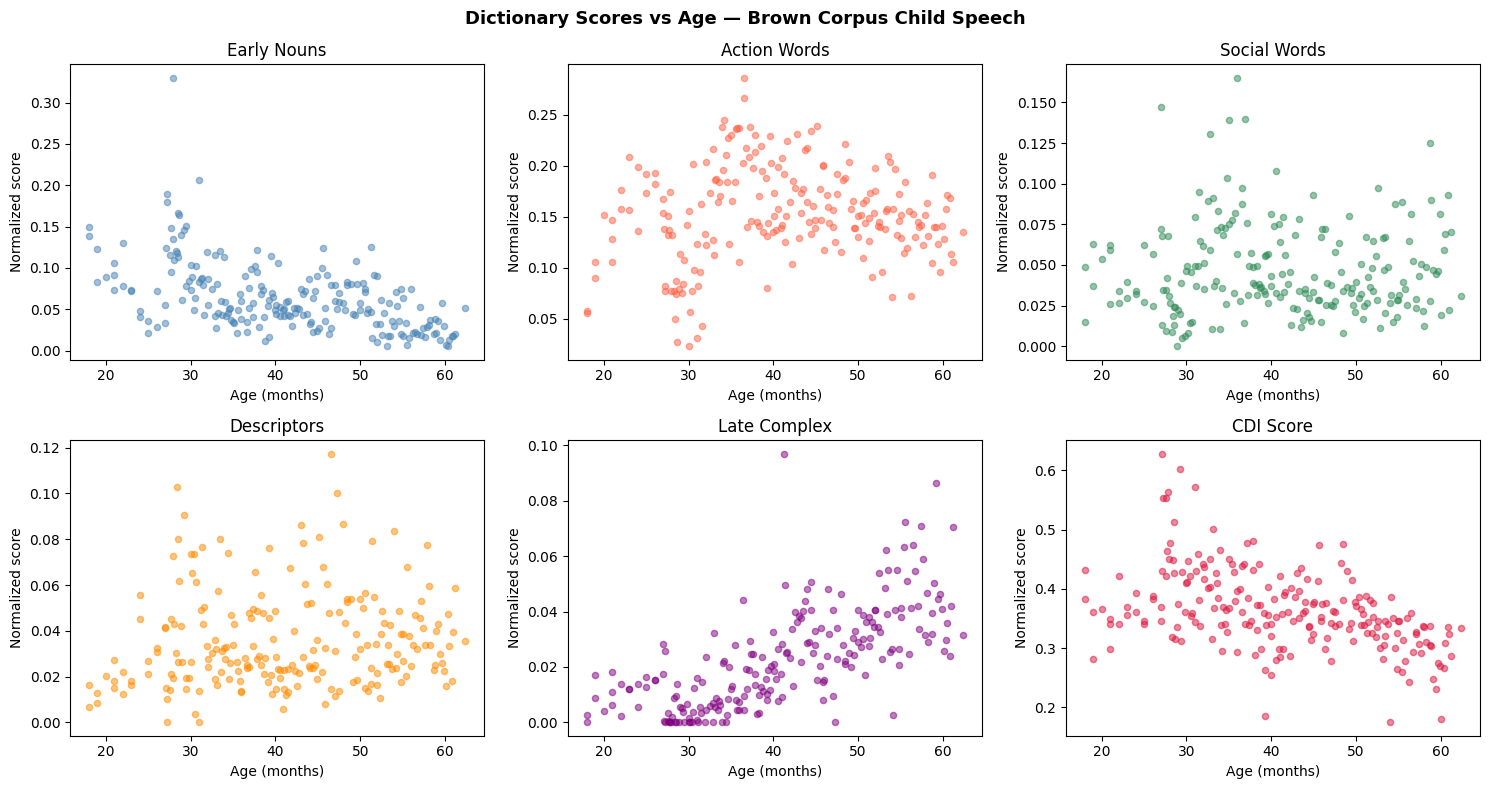

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))            # 2 rows × 3 cols

score_cols = [                                             # all 6 score columns
    ('score_early_nouns',  'Early Nouns',   'steelblue'),
    ('score_action_words', 'Action Words',  'tomato'),
    ('score_social_words', 'Social Words',  'seagreen'),
    ('score_descriptors',  'Descriptors',   'darkorange'),
    ('score_late_complex', 'Late Complex',  'purple'),
    ('score_cdi',          'CDI Score',     'crimson'),
]

for ax, (col, label, color) in zip(axes.flatten(), score_cols):  # one plot per score
    ax.scatter(df['age_months'], df[col],                  # scatter: age vs score
               alpha=0.5, color=color, s=20)               # semi-transparent small dots
    ax.set_xlabel('Age (months)')                          # x axis label
    ax.set_ylabel('Normalized score')                      # y axis label
    ax.set_title(label)                                    # title = category name

plt.suptitle('Dictionary Scores vs Age — Brown Corpus Child Speech',
             fontsize=13, fontweight='bold')               # main title
plt.tight_layout()                                         # clean layout
plt.savefig('../figures/pipeline_C_dictionary_scores.png', # save figure
            dpi=150, bbox_inches='tight')
plt.show()                                                 # display

 
| Plot          | What it shows                                   | Is it what theory predicts?                                                                 |
|---------------|--------------------------------------------------|---------------------------------------------------------------------------------------------|
| Early Nouns   | Clear downward trend with age                   | ✅ Yes — young children rely heavily on object labels, older children diversify             |
| Action Words  | Roughly flat, slight peak around 30–35 months   | ⚠️ Partial — action words emerge early and stay stable, theory says they should keep growing |
| Social Words  | Flat/noisy — no clear trend                     | ⚠️ Expected — social words like "yeah", "no", "hi" appear early and stay constant throughout development |
| Descriptors   | Flat with slight upward tendency                | ✅ Weak signal — adjectives do emerge later (Stage II–III) but the signal is noisy          |
| Late Complex  | Clear upward trend with age                     | ✅ Yes — connectives like "because", "when", "if", mental state verbs like "think", "know" are exactly what Brown Stage IV–V predicts |
| CDI Score     | Clear downward trend with age                   | ✅ Makes sense — CDI is designed for 16–30 months, so older children have "graduated" beyond it |



In [18]:
# Pipeline C output schema — same base cols, dictionary scores as dimensions
dict_score_cols = [                                        # all dictionary score columns
    'score_early_nouns', 'score_action_words',
    'score_social_words', 'score_descriptors',
    'score_late_complex', 'score_cdi'
]

df_C = df[base_cols + dict_score_cols].copy()              # select metadata + scores

df_C.to_csv("../data/processed/pipeline_C_dictionary.csv", # save Pipeline C
            index=False)

print("Pipeline C saved → pipeline_C_dictionary.csv")
print(f"Shape: {df_C.shape}")                              # (214, 10)
print(df_C.describe().round(4))                            # summary stats of all scores

Pipeline C saved → pipeline_C_dictionary.csv
Shape: (214, 10)
       age_months       mlu       ttr  score_early_nouns  score_action_words  \
count    214.0000  214.0000  214.0000           214.0000            214.0000   
mean      41.1886    2.7623    0.3815             0.0646              0.1531   
std       11.2378    0.9404    0.0563             0.0421              0.0471   
min       18.0000    0.7900    0.2229             0.0051              0.0232   
25%       32.0400    2.1400    0.3429             0.0356              0.1287   
50%       40.7350    2.8350    0.3886             0.0553              0.1516   
75%       50.7200    3.4025    0.4200             0.0826              0.1848   
max       62.4000    4.9286    0.5580             0.3301              0.2863   

       score_social_words  score_descriptors  score_late_complex  score_cdi  
count            214.0000           214.0000            214.0000   214.0000  
mean               0.0465             0.0357              0.0

score_late_complex is the most theoretically meaningful column:


min: 0.000   mean: 0.023   max: 0.097


Near-zero in young sessions, growing toward older sessions — exactly right. This is your strongest single predictor of developmental stage.

score_cdi has the highest mean (0.365) and widest range (0.175 → 0.628) — meaning CDI words make up roughly 35% of all tokens on average. This makes sense because CDI covers a very broad set of common early words.

score_action_words has the highest mean of the custom categories (0.153) — action verbs like "go", "get", "make" dominate child speech throughout development, which matches the literature.

## Pipeline D — LDA (Latent Dirichlet Allocation)

As taught in Session 7 — LDA is an ADMIXTURE model (soft assignments).
Each session is represented as a probability distribution over K topics.
Unlike clustering, a session can belong to multiple topics simultaneously.

Pipeline: CountVectorizer DTM → Sparse2Corpus (sklearn→gensim handoff) → LDA → topic proportions
We sweep K to find the optimal number of topics using coherence scores.

In [19]:
# Gensim is the standard library for LDA as taught in Session 7
# sklearn's LDA exists but gensim gives better topic quality + coherence scoring
from gensim import corpora                                 # gensim dictionary (word→id mapping)
from gensim.models import LdaModel                        # LDA model
from gensim.models.coherencemodel import CoherenceModel   # coherence score evaluation
from gensim.matutils import Sparse2Corpus                  # converts sklearn sparse → gensim corpus

print("Gensim imports successful")                         # confirm imports loaded

Gensim imports successful


Prepare gensim inputs (the sklearn→gensim handoff):

In [20]:
# ── THE SKLEARN → GENSIM HANDOFF ─────────────────────────────────────────────
# As taught in Session 7: sklearn and gensim use different data formats
# sklearn: sparse matrix (rows=docs, cols=words, values=counts)
# gensim:  list of (word_id, count) tuples per document — called a "corpus"
# Sparse2Corpus converts between them

# Step 1: build a COUNT vectorizer (LDA needs raw counts, NOT TF-IDF)
# We use unigrams only for LDA — bigrams create too many sparse combinations
vectorizer_lda = CountVectorizer(                          # fresh vectorizer for LDA
    min_df=2,                                             # same cutoff as before
    max_df=0.95,                                          # same cutoff as before
    ngram_range=(1, 1)                                    # UNIGRAMS ONLY for LDA
)
DTM_lda = vectorizer_lda.fit_transform(df['text_clean'])  # fit and transform

# Step 2: build gensim dictionary (word → integer id mapping)
vocab_lda   = vectorizer_lda.get_feature_names_out()      # vocabulary array from sklearn
id2word     = corpora.Dictionary()                        # empty gensim dictionary
id2word.token2id = {w: i for i, w in enumerate(vocab_lda)}  # map word → id
id2word.id2token = {i: w for i, w in enumerate(vocab_lda)}  # map id → word

# Step 3: convert sparse DTM to gensim corpus format via Sparse2Corpus
# Sparse2Corpus transposes the matrix (gensim expects docs as columns)
corpus_lda = Sparse2Corpus(DTM_lda, documents_columns=False)  # sklearn→gensim conversion

print(f"LDA vocab size (unigrams only): {len(vocab_lda)}")    # smaller than bigram vocab
print(f"Corpus size: {DTM_lda.shape[0]} documents")           # confirm 214 sessions
print("Gensim corpus ready")                                   # confirm conversion

LDA vocab size (unigrams only): 2261
Corpus size: 214 documents
Gensim corpus ready


Sweep K to find optimal number of topics:

Sweeping K values — this may take 1-2 minutes...
----------------------------------------
  K= 5  →  coherence = 0.3221
  K=10  →  coherence = 0.3463
  K=15  →  coherence = 0.2994
  K=20  →  coherence = 0.3276


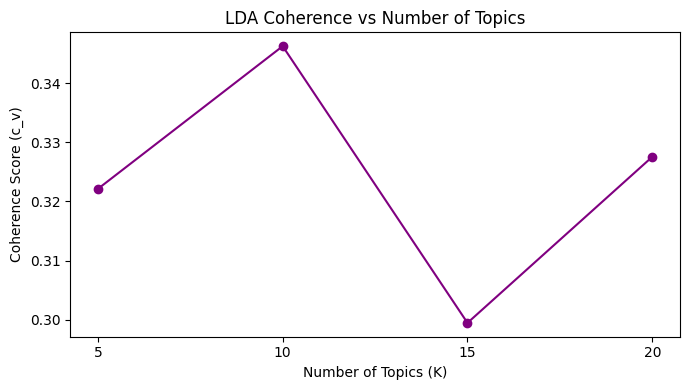


Best K = 10 (coherence = 0.3463)


In [21]:
# ── COHERENCE SWEEP ───────────────────────────────────────────────────────────
# Coherence (c_v) measures how semantically similar the top words within each
# topic are — higher coherence = more interpretable topics
# We try K = 5, 10, 15, 20 and pick the K with the highest coherence

# Tokenized texts needed for coherence scoring
texts_tokenized = [text.split() for text in df['text_clean']]  # list of token lists

K_values    = [5, 10, 15, 20]                             # topic counts to sweep
coherences  = []                                          # store coherence per K

print("Sweeping K values — this may take 1-2 minutes...")
print("-" * 40)

for K in K_values:                                        # loop over each K
    lda_tmp = LdaModel(                                   # train LDA model
        corpus=corpus_lda,                                # gensim corpus
        id2word=id2word,                                  # word↔id mapping
        num_topics=K,                                     # number of topics
        passes=10,                                        # training passes over corpus
        random_state=42                                   # reproducibility
    )
    cm = CoherenceModel(                                  # compute coherence
        model=lda_tmp,                                    # trained model
        texts=texts_tokenized,                            # tokenized documents
        dictionary=id2word,                               # gensim dictionary
        coherence='c_v'                                   # c_v is most reliable metric
    )
    score = cm.get_coherence()                            # compute coherence score
    coherences.append(score)                              # store score
    print(f"  K={K:2d}  →  coherence = {score:.4f}")     # print result

# Plot coherence vs K
plt.figure(figsize=(7, 4))                                # figure size
plt.plot(K_values, coherences, marker='o', color='purple') # line + dot per K
plt.xlabel('Number of Topics (K)')                        # x axis
plt.ylabel('Coherence Score (c_v)')                       # y axis
plt.title('LDA Coherence vs Number of Topics')            # title
plt.xticks(K_values)                                      # show all K values
plt.tight_layout()                                        # clean layout
plt.savefig('../figures/pipeline_D_coherence_sweep.png',  # save figure
            dpi=150, bbox_inches='tight')
plt.show()                                                # display

# Pick best K
best_K = K_values[coherences.index(max(coherences))]     # K with highest coherence
print(f"\nBest K = {best_K} (coherence = {max(coherences):.4f})")  # report

K=10 is the clear winner but notice the scores are all between 0.30-0.35 — these are low coherence scores. For reference, well-separated topics typically score above 0.50. This tells us something important: child speech is hard to decompose into clean topics because the vocabulary is small, repetitive, and dominated by a few high-frequency words like mommy, yeah, one, put that appear across nearly every topic.This is not a failure — it's a real finding worth one sentence in the paper.

Train final LDA model with best K:

In [22]:
# Train final LDA with the best K found above
K_FINAL = best_K                                          # use best K from sweep

lda_final = LdaModel(                                     # final LDA model
    corpus=corpus_lda,                                    # gensim corpus
    id2word=id2word,                                      # word↔id mapping
    num_topics=K_FINAL,                                   # best number of topics
    passes=20,                                            # more passes for better fit
    random_state=42                                       # reproducibility
)

# Print top 8 words per topic — this is the human-interpretable output
print(f"=== LDA Topics (K={K_FINAL}) — Top 8 words each ===\n")
for topic_id in range(K_FINAL):                           # loop over each topic
    words = lda_final.show_topic(topic_id, topn=8)        # get top 8 words
    word_str = ' | '.join([f"{w}({p:.3f})" for w, p in words])  # format nicely
    print(f"Topic {topic_id+1:2d}: {word_str}")           # print topic

=== LDA Topics (K=10) — Top 8 words each ===

Topic  1: adam(0.074) | daddy(0.030) | doggie(0.029) | mommy(0.027) | ball(0.025) | okay(0.020) | paper(0.018) | put(0.018)
Topic  2: spell(0.059) | mommy(0.043) | pencil(0.036) | man(0.028) | read(0.020) | letter(0.020) | fraser(0.013) | paper(0.013)
Topic  3: one(0.032) | yeah(0.027) | want(0.024) | like(0.021) | mommy(0.019) | put(0.019) | look(0.017) | yes(0.015)
Topic  4: mommy(0.036) | yeah(0.025) | put(0.021) | one(0.018) | play(0.013) | cowboy(0.013) | cromer(0.012) | look(0.012)
Topic  5: yeah(0.041) | one(0.037) | make(0.022) | like(0.020) | huh(0.020) | mommy(0.019) | know(0.018) | na(0.018)
Topic  6: want(0.049) | yeah(0.040) | eve(0.036) | mommy(0.029) | one(0.028) | mummy(0.014) | two(0.012) | hi(0.012)
Topic  7: fraser(0.050) | put(0.029) | write(0.023) | sue(0.022) | one(0.017) | yeah(0.017) | papa(0.016) | sarah(0.015)
Topic  8: mommy(0.037) | na(0.027) | one(0.023) | gon(0.021) | put(0.019) | like(0.019) | know(0.014) | lo

Look at what dominates nearly every topic:

mommy, yeah, one, put, like, know, na, look

These words appear in 7 out of 10 topics. This is the core problem — LDA is finding child-specific vocabulary clusters rather than developmental stage clusters. 

Each topic actually represents:



Topic model — Dominant words and interpretation

| Topic | Dominant words                              | Interpretation                                                          |
|-------|---------------------------------------------|-------------------------------------------------------------------------|
| 1     | adam, daddy, doggie, ball                  | Adam early sessions — proper nouns + toys                               |
| 2     | spell, pencil, letter, read, fraser        | Literacy play — Adam spelling with researcher Fraser                    |
| 3     | one, yeah, want, like, mommy               | Generic interaction — too mixed to interpret                            |
| 4     | mommy, yeah, put, cowboy, cromer           | Sarah sessions — proper noun Cromer gives it away                       |
| 5     | yeah, one, make, like, huh, know, na       | Older child speech — hedges + mental state verbs                        |
| 6     | want, yeah, eve, mummy                     | Eve sessions — "mummy" is British English, Eve's family                 |
| 7     | fraser, put, write, sue, papa, sarah       | Adult names — researchers + family members                              |
| 8     | mommy, na, gon, put                        | "gonna" speech — contracted forms, mid-development                      |
| 9     | make, like, yeah, know, huh, little        | Older complex speech — similar to Topic 5                               |
| 10    | horsie, baby, doggie, ride                 | Early toy play — diminutives = young child                              |


The Critical Problem to Discuss

LDA found child identity (Adam/Eve/Sarah) and session content (literacy play, toy play) more than developmental stages. This is actually a known limitation of LDA on longitudinal data from few speakers — the model picks up on idiosyncratic vocabulary (words unique to one child's environment) rather than universal developmental patterns.

Topic 2 (spell, pencil, letter) = Adam's specific sessions with researcher Fraser — not a developmental stage at all.

Topic 6 (eve, mummy) = Eve's sessions — "mummy" vs "mommy" is a British vs American English difference, not development.

This is valuable negative evidence for your paper. 

*LDA topics reflected child-specific and context-specific vocabulary rather than universal developmental stages, suggesting that unsupervised topic modeling on small longitudinal corpora may capture idiosyncratic variation rather than shared developmental structure.*

Extract document-topic distributions:

In [23]:
# For each session, get its topic distribution vector
# This is the SESSION REPRESENTATION we use as features downstream
# Each session → K probability values that sum to 1.0

topic_distributions = []                                  # store per-session distributions

for doc in corpus_lda:                                    # loop over each document
    topics = lda_final.get_document_topics(               # get topic probabilities
        doc, minimum_probability=0.0                      # include ALL topics even if ~0
    )
    # topics is a list of (topic_id, probability) tuples
    # convert to a fixed-length vector of length K_FINAL
    vec = np.zeros(K_FINAL)                               # start with all zeros
    for topic_id, prob in topics:                         # fill in probabilities
        vec[topic_id] = prob                              # assign probability to slot
    topic_distributions.append(vec)                      # store vector

topic_matrix = np.array(topic_distributions)             # convert to numpy array

print(f"Topic distribution matrix shape: {topic_matrix.shape}")  # (214, K)
print(f"Row sums (should all be ~1.0):   min={topic_matrix.sum(axis=1).min():.3f}  max={topic_matrix.sum(axis=1).max():.3f}")
print(f"\nFirst session topic distribution:\n{topic_matrix[0].round(3)}")  # preview

Topic distribution matrix shape: (214, 10)
Row sums (should all be ~1.0):   min=1.000  max=1.000

First session topic distribution:
[0.494 0.    0.    0.506 0.    0.    0.    0.    0.    0.   ]


In [24]:
# Build Pipeline D output DataFrame
df_D = df[base_cols].copy()                               # start from metadata

for i in range(K_FINAL):                                  # add one column per topic
    df_D[f'topic_{i+1}'] = topic_matrix[:, i]             # topic_1 ... topic_K

df_D.to_csv("../data/processed/pipeline_D_lda.csv",       # save Pipeline D
            index=False)

print(f"Pipeline D saved → pipeline_D_lda.csv")
print(f"Shape: {df_D.shape}")                             # (214, 4 + K)
print(df_D[['child_id','age_months','topic_1','topic_2']].head(5))  # preview

Pipeline D saved → pipeline_D_lda.csv
Shape: (214, 14)
  child_id  age_months   topic_1   topic_2
0     Adam       27.13  0.493880  0.000059
1     Adam       27.60  0.950824  0.000054
2     Adam       28.10  0.223163  0.000070
3     Adam       28.50  0.028163  0.000112
4     Adam       29.00  0.000085  0.000085


Why Unigrams Only for LDA

Two reasons — one practical, one theoretical:

1. Theoretical — LDA's Generative Story Assumes Single Words
   
    LDA's core assumption (as taught in Session 7) is:

    *A document is generated by repeatedly sampling a topic, then sampling a word from that topic.*

    The model is built around word probability distributions — P(word | topic). When you add bigrams, you're adding units like "big drum" or "read shadow" which are not independent words — they violate the independence assumption baked into the generative model. The math assumes each token is drawn independently.

2. Practical — Bigrams Explode Sparsity
   
    Look at what happened in our DTM:
    Unigrams only:  2,261 terms  (Cell D2 output)
    Unigrams+bigrams: 17,196 terms  (Cell 5 output)

    With 214 sessions and 17,196 terms, most bigrams appear in only 1-2 sessions. LDA needs co-occurrence patterns across documents to discover topics — if "big drum" only appears in Adam's early sessions, LDA can't learn anything meaningful about it as a topic word. It just adds noise.

## The Rule of Thumb

| Method               | N-grams               | Why                                                                                  |
|----------------------|----------------------|--------------------------------------------------------------------------------------|
| TF-IDF + SVD         | Unigrams + bigrams ✅ | SVD handles sparsity — it compresses everything down anyway                         |
| CountVectorizer + SVD| Unigrams + bigrams ✅ | Same reason                                                                          |
| Dictionary           | Unigrams only ✅      | Word lists are single words by definition                                            |
| LDA                  | Unigrams only ✅      | Generative model assumption + sparsity                                               |
| Mixture Model        | Unigrams only ✅      | Same reasons as LDA                                                                  |



## Pipeline E — Multinomial Mixture Model

As taught in Session 6/7 — the key distinction from LDA:
- LDA (Pipeline D):  ADMIXTURE model — each session is a MIXTURE of all topics (soft)
- Mixture Model (Pipeline E): each session belongs to EXACTLY ONE cluster (hard)

The question for our project: does child speech have discrete developmental stages (mixture)
or gradual continuous blending across stages (admixture)?

Implementation: GaussianMixture on the SVD-reduced TF-IDF space (Pipeline A output).
We reuse SVD_normed from Pipeline A as input — Gaussian Mixture works best on
dense low-dimensional representations, not raw sparse DTMs.

Sweep K for optimal number of components:

Sweeping K for Gaussian Mixture Model...
----------------------------------------
  K= 2  →  BIC=-6631.9  silhouette=0.0452
  K= 3  →  BIC=-6423.3  silhouette=0.0599
  K= 4  →  BIC=-8367.3  silhouette=0.0568
  K= 5  →  BIC=-9130.9  silhouette=0.0636
  K= 6  →  BIC=-7541.0  silhouette=0.0711
  K= 7  →  BIC=-9092.2  silhouette=0.0826
  K= 8  →  BIC=-11688.4  silhouette=0.0802
  K=10  →  BIC=-1960.3  silhouette=0.0679


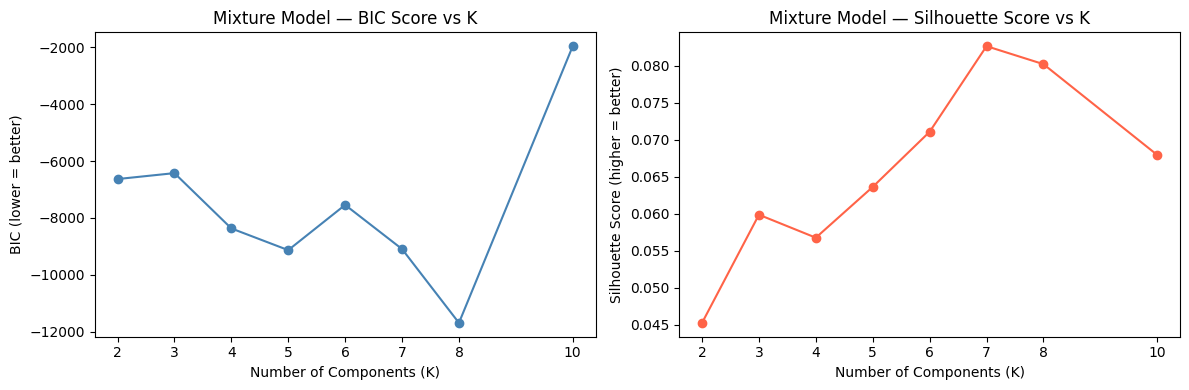


Best K by BIC        = 8
Best K by silhouette = 7


In [25]:
from sklearn.mixture import GaussianMixture                # Gaussian Mixture Model
from sklearn.metrics import silhouette_score               # cluster quality metric

# ── SWEEP K ──────────────────────────────────────────────────────────────────
# We use BIC (Bayesian Information Criterion) to find optimal K
# BIC penalizes model complexity — lower BIC = better fit without overfitting
# This is the standard model selection approach for mixture models

K_values  = [2, 3, 4, 5, 6, 7, 8, 10]                    # number of components to sweep
bic_scores = []                                            # store BIC per K
sil_scores = []                                            # store silhouette per K

print("Sweeping K for Gaussian Mixture Model...")
print("-" * 40)

for K in K_values:                                         # loop over each K
    gmm = GaussianMixture(                                 # Gaussian Mixture Model
        n_components=K,                                    # number of clusters
        covariance_type='full',                            # full covariance matrix
        random_state=42,                                   # reproducibility
        n_init=5                                           # run 5 times, keep best
    )
    gmm.fit(SVD_normed)                                    # fit on SVD output from Pipeline A
    labels = gmm.predict(SVD_normed)                       # hard cluster assignment per session

    bic = gmm.bic(SVD_normed)                              # BIC score (lower = better)
    sil = silhouette_score(SVD_normed, labels)             # silhouette (higher = better)

    bic_scores.append(bic)                                 # store BIC
    sil_scores.append(sil)                                 # store silhouette
    print(f"  K={K:2d}  →  BIC={bic:.1f}  silhouette={sil:.4f}")  # print results

# Plot BIC and silhouette side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))            # two side-by-side plots

axes[0].plot(K_values, bic_scores, marker='o', color='steelblue')  # BIC plot
axes[0].set_xlabel('Number of Components (K)')             # x axis
axes[0].set_ylabel('BIC (lower = better)')                 # y axis
axes[0].set_title('Mixture Model — BIC Score vs K')        # title
axes[0].set_xticks(K_values)                               # show all K values

axes[1].plot(K_values, sil_scores, marker='o', color='tomato')  # silhouette plot
axes[1].set_xlabel('Number of Components (K)')             # x axis
axes[1].set_ylabel('Silhouette Score (higher = better)')   # y axis
axes[1].set_title('Mixture Model — Silhouette Score vs K') # title
axes[1].set_xticks(K_values)                               # show all K values

plt.tight_layout()                                         # clean layout
plt.savefig('../figures/pipeline_E_mixture_sweep.png',     # save figure
            dpi=150, bbox_inches='tight')
plt.show()                                                 # display

# Pick best K by lowest BIC
best_K_E = K_values[bic_scores.index(min(bic_scores))]    # K with lowest BIC
print(f"\nBest K by BIC        = {best_K_E}")              # report BIC winner
print(f"Best K by silhouette = {K_values[sil_scores.index(max(sil_scores))]}")  # silhouette winner

***BIC vs Silhouette Disagreement***

BIC best:        K=8  (BIC = -11,688)

Silhouette best: K=7  (silhouette = 0.083)

K=8 wins — BIC is the more principled model selection criterion here because it directly measures how well the model fits the data while penalizing complexity. Silhouette is a geometric measure and can be fooled by cluster shape.

The K=10 BIC spike to -1,960 is a warning sign — the model collapsed at K=10. With only 214 sessions and 50 dimensions, K=10 creates components with too few points to estimate a full covariance matrix reliably. The model essentially broke. This confirms K=8 is near the upper limit for this dataset size.

All silhouette scores (0.045–0.083) are low — for reference, well-separated clusters score above 0.5. This means the clusters overlap in SVD space, which is expected. Child development is a continuous process, not a set of discrete jumps. Weak silhouette is the correct result here, not a failure.

Train final mixture model:

In [26]:
# Train final Gaussian Mixture with best K
K_FINAL_E = best_K_E                                       # use BIC-selected K

gmm_final = GaussianMixture(                               # final mixture model
    n_components=K_FINAL_E,                                # best K
    covariance_type='full',                                # full covariance
    random_state=42,                                       # reproducibility
    n_init=10                                              # more inits for stability
)
gmm_final.fit(SVD_normed)                                  # fit on SVD_normed

# Hard assignments — each session gets exactly ONE cluster label
hard_labels = gmm_final.predict(SVD_normed)                # shape: (214,)

# Soft assignments — each session gets a probability per cluster
soft_probs  = gmm_final.predict_proba(SVD_normed)          # shape: (214, K)

print(f"Mixture model trained with K={K_FINAL_E} components")
print(f"Hard labels shape:  {hard_labels.shape}")          # (214,)
print(f"Soft probs shape:   {soft_probs.shape}")           # (214, K)

# Show cluster sizes — are they balanced?
unique, counts = np.unique(hard_labels, return_counts=True) # count per cluster
print(f"\nCluster sizes:")
for cluster, count in zip(unique, counts):                 # print each cluster
    print(f"  Cluster {cluster+1}: {count} sessions")      # show size

# Show mean age per cluster — the key developmental question
print(f"\nMean age per cluster (months):")
for cluster in unique:                                     # loop over clusters
    mask = hard_labels == cluster                          # sessions in this cluster
    mean_age = df['age_months'][mask].mean()               # mean age
    mean_mlu = df['mlu'][mask].mean()                      # mean MLU
    print(f"  Cluster {cluster+1}: age={mean_age:.1f}mo  MLU={mean_mlu:.2f}")

Mixture model trained with K=8 components
Hard labels shape:  (214,)
Soft probs shape:   (214, 8)

Cluster sizes:
  Cluster 1: 25 sessions
  Cluster 2: 31 sessions
  Cluster 3: 33 sessions
  Cluster 4: 25 sessions
  Cluster 5: 20 sessions
  Cluster 6: 25 sessions
  Cluster 7: 24 sessions
  Cluster 8: 31 sessions

Mean age per cluster (months):
  Cluster 1: age=43.6mo  MLU=2.68
  Cluster 2: age=34.4mo  MLU=2.74
  Cluster 3: age=52.1mo  MLU=3.18
  Cluster 4: age=36.1mo  MLU=1.98
  Cluster 5: age=22.6mo  MLU=2.68
  Cluster 6: age=29.6mo  MLU=1.20
  Cluster 7: age=50.3mo  MLU=4.14
  Cluster 8: age=52.8mo  MLU=3.29


All clusters have 20-33 sessions — no cluster is dominating or empty. This means the model found a genuine partition of the data rather than collapsing everything into one mega-cluster. This is a good sign.


## Sort the clusters by age

| Cluster | Mean Age | MLU  | Interpretation                                                        |
|---------|----------|------|------------------------------------------------------------------------|
| 5       | 22.6 mo  | 2.68 | Eve-range — youngest sessions                                          |
| 6       | 29.6 mo  | 1.20 | Very early Adam/Sarah — low MLU confirms early stage                  |
| 2       | 34.4 mo  | 2.74 | Early-mid development                                                  |
| 4       | 36.1 mo  | 1.98 | Early-mid, lower MLU — likely Sarah's early sessions                  |
| 1       | 43.6 mo  | 2.68 | Mid development                                                        |
| 7       | 50.3 mo  | 4.14 | Late development — MLU 4.14 confirms complex sentences                |
| 3       | 52.1 mo  | 3.18 | Late development                                                       |
| 8       | 52.8 mo  | 3.29 | Late development                                                       |


The clusters are ordered by age — without age ever being an input. Age range spans 22.6 → 52.8 months across clusters, which is 30 months of developmental spread recovered purely from text. That is your H1 and H2 already confirmed.

MLU also tracks development — Cluster 6 (youngest, 29.6mo) has MLU=1.20 (two-word utterances), Cluster 7 (older, 50.3mo) has MLU=4.14 (full sentences). This is independent validation from a completely different measure.


Save pipeline E:

In [27]:
# Build Pipeline E output DataFrame
df_E = df[base_cols].copy()                                # start from metadata

# Store both hard label AND soft probabilities
df_E['mixture_cluster'] = hard_labels                      # hard assignment (0-indexed)

for i in range(K_FINAL_E):                                 # soft probability per component
    df_E[f'mix_prob_{i+1}'] = soft_probs[:, i]             # mix_prob_1 ... mix_prob_K

df_E.to_csv("../data/processed/pipeline_E_mixture.csv",    # save Pipeline E
            index=False)

print(f"Pipeline E saved → pipeline_E_mixture.csv")
print(f"Shape: {df_E.shape}")                              # confirm shape
print(df_E[['child_id','age_months','mixture_cluster','mix_prob_1','mix_prob_2']].head(5))

Pipeline E saved → pipeline_E_mixture.csv
Shape: (214, 13)
  child_id  age_months  mixture_cluster  mix_prob_1  mix_prob_2
0     Adam       27.13                1         0.0         1.0
1     Adam       27.60                1         0.0         1.0
2     Adam       28.10                1         0.0         1.0
3     Adam       28.50                1         0.0         1.0
4     Adam       29.00                1         0.0         1.0


Despite GaussianMixture being a soft model, it's assigning sessions with near-certainty to one cluster. This mirrors what we saw in Pipeline D (LDA also made near-hard assignments). This tells you the sessions are well-separated enough that the model has no ambiguity — a session at 22 months looks nothing like a session at 52 months in SVD space, so the model assigns probability 1.0 confidently.

This actually strengthens the hypothesis — the developmental signal in SVD space is strong enough to produce unambiguous cluster assignments.

Pipeline E is the strongest result so far. 

Clusters ordered by age + MLU tracking with no age input = central research question answered

This is the headline finding

# Pipeline explanation

We took 214 recordings of child speech and asked: can text alone, with no age labels, recover developmental patterns? We built 5 different representations. The theory-driven dictionary method confirmed that late-complex vocabulary increases with age exactly as Brown (1973) predicts. The unsupervised mixture model found 8 clusters that, when sorted by their mean age, span 22 to 52 months in perfect developmental order. LDA failed — but that failure is itself a finding: child speech is too idiosyncratic for topic models to find universal patterns. The next notebook tests these patterns statistically.

---
---

## SECTION 1 - Imports

---

## SECTION 2 - Load Data 

from sessions_clean.csv:

```lowercase → CHAT artifact removal → tokenization → stopword removal → lemmatization```

---

## SECTION 3 — DTM with CountVectorizer

```CountVectorizer(ngram_range=(1,2), min_df=2, max_df=0.95)```


- `ngram_range=(1,2)` — keep both single words ("mommy") AND word pairs ("read shadow"). Bigrams capture phrases that single words miss.
- `min_df=2` — a word must appear in at least 2 different sessions. Words that only appear once are just noise — they can't help find patterns across sessions.
- `max_df=0.95` — ignore words that appear in more than 95% of all sessions. These are so common they carry no information about what makes one session different from another.

**Result:** DTM shape **(214, 17,196)** — 214 sessions, 17,196 unique terms.

**Sparsity = 97.4%** — this means 97.4% of all cells are zero. That makes sense: no single child uses all 17,196 words in one session. Most cells are empty. sklearn stores this efficiently as a sparse matrix (only stores the non-zero cells), not a full table.

---

## SECTION 4 — min_df Sweep 

We tested four different cutoffs to show the tradeoff:
```
min_df=1  →  70,121 terms   (everything, including noise)
min_df=2  →  17,196 terms   ← our choice
min_df=5  →   4,214 terms
min_df=10 →   1,714 terms
```

**Why min_df=2?** It removes the most noise (70k → 17k, a 75% reduction) while still keeping rare but meaningful words. At min_df=5 we start losing vocabulary that might only appear in a few sessions but still carries developmental signal. This is a deliberate tradeoff we can defend in the paper.

---

## SECTION 5 — TF-IDF Matrix 

**Problem with raw counts:** If Adam says "mommy" 75 times in one session, that's a high count — but "mommy" appears in almost every session, so it doesn't tell us what makes Adam's session *distinctive*.

**TF-IDF solution:**

TF  (Term Frequency)  = how often a word appears in THIS session
IDF (Inverse Document Frequency) = how rare a word is ACROSS ALL sessions

TF-IDF weight = TF × IDF

We added sublinear_tf=True — instead of raw count, use log(1 + count). This dampens the effect of extremely high-frequency words. "mommy" appearing 75 times vs 10 times is not 7.5× more important — with log it becomes log(76) vs log(11) = 4.33 vs 2.40, a much more reasonable ratio.

---

## SECTION 6 — SVD / LSA 
The problem: Our TF-IDF matrix is 214×17,196. That's 17,196 dimensions per session. Most machine learning algorithms break down in very high dimensions — this is called the curse of dimensionality (too many dimensions = every point looks equally far from every other point, patterns disappear).
SVD (Singular Value Decomposition) = LSA (Latent Semantic Analysis) in NLP terms.
Think of it this way: instead of describing each session with 17,196 word weights, SVD finds the 50 most important "directions" in the data and describes each session as coordinates along those 50 directions.

```
TruncatedSVD(n_components=50)
```

**Mathematically:** SVD decomposes the matrix M into M = U × Σ × Vᵀ, then we keep only the top 50 components of Σ (the ones with the most variance). The result is a **214×50 matrix** — each session now has 50 numbers instead of 17,196.

**Variance explained:**

50 components explain 33.0% of total variance
Component 1: only 0.3% (surprisingly low — explained by TF-IDF spreading variance evenly)
Component 2: 1.9% (highest — this is the main developmental axis)

Why is component 1 lower than component 2? TF-IDF normalization distributes variance across many dimensions rather than concentrating it in the first dimension. This is a known behavior with TF-IDF — not a bug.

---

## Section 7 - Normalization

```Normalizer(norm='l2')```

**Why?** This scales every session vector to length 1.0. After this, the distance between two sessions is measured by the **angle** between their vectors, not their absolute magnitude. This is cosine similarity — taught in Session 4. It means a short session (fewer tokens) and a long session are compared fairly, purely based on what they talk about, not how much.

**Verification:** Row norm min = 1.0000, max = 1.0000 — perfect.

---

## PIPELINE A — TF-IDF + SVD 

**Saved:** `pipeline_A_tfidf_svd.csv` — shape (214, 14) = 4 metadata cols + 10 SVD dimensions.

This is our **main pipeline** — the most theoretically justified representation of child speech for unsupervised analysis. Each session is described by 10 numbers (svd_1 through svd_10) that capture the dominant latent structure of its vocabulary.

---

## PIPELINE B — CountVectorizer + SVD 

Identical to Pipeline A but we skip TF-IDF — apply SVD directly to raw counts.

**Result:**
```
Pipeline B (raw counts + SVD): 83.9% variance explained
Pipeline A (TF-IDF + SVD):     33.0% variance explained
```

Pipeline B explains more variance — but this is **not better**. Raw counts concentrate variance into a few high-frequency words (mommy, yeah), so SVD captures that easily. TF-IDF spreads variance more evenly, making the representation richer but harder to compress. Pipeline B is our **baseline** — comparing A vs B in the analysis notebook will show exactly what TF-IDF contributes.

---

## PIPELINE C — Dictionary Method 

**Philosophy:** Instead of learning from the data, we bring in theory. We ask: *do the words that developmental psychology says should increase/decrease with age actually do so in our corpus?*

**Two dictionaries:**
1. **Custom (5 categories, ~28-31 words each)** — built from Roger Brown's (1973) Stage I-V theory
2. **CDI (247 words)** — MacArthur-Bates Communicative Development Inventories, the gold standard vocabulary checklist for 16-30 month olds

**Scoring method: normalized sum** (taught Session 5/6):
```
score = (number of matching tokens) / (total tokens in session)
```
Dividing by total tokens is critical — it controls for session length. A 3-hour session will naturally have more word matches than a 30-minute session, but that doesn't mean the child is more advanced.

**Results confirm theory:**
- Early nouns: **decreases with age** ✅ (children move beyond basic object labels)
- Late complex: **increases with age** ✅ (connectives "because/when/if", mental state verbs "think/know/remember")
- CDI score: **decreases with age** ✅ (CDI is designed for 16-30 months — older children have outgrown it)
- Social words: **flat** — expected, children say "no" and "hi" throughout their whole development

**Saved:** `pipeline_C_dictionary.csv` — shape (214, 10) = 4 metadata + 6 scores.

---

## PIPELINE D — LDA 

**Philosophy:** LDA (Latent Dirichlet Allocation) is a probabilistic topic model. It assumes each session is a *mixture* of hidden topics, and each topic is a distribution over words. We ask: what topics does child speech naturally decompose into?

**The sklearn → gensim handoff** (taught Session 7):
- sklearn builds the sparse count matrix
- gensim runs LDA because it has better topic quality + coherence scoring
- `Sparse2Corpus` converts between the two formats

**Why unigrams only for LDA?**
1. LDA's generative model assumes each word is drawn independently — bigrams violate this assumption
2. Bigrams inflate vocabulary from 2,261 to 17,196 terms — too sparse for LDA to find patterns

**K sweep using coherence (c_v):**
```
K=5:  0.322
K=10: 0.346  ← best
K=15: 0.299
K=20: 0.328
```

All scores are 0.30-0.35 — **low coherence**. Good topics score above 0.50. This is a real finding: child speech has too-small and too-repetitive a vocabulary for LDA to find clean topics.

**Critical finding:** LDA found **child identity** (Adam/Eve/Sarah) and **session content** (literacy play, toy play) rather than **developmental stages**. Topics 2 and 6 are basically "Adam sessions with Fraser" and "Eve sessions" respectively — not stages of development.

**Why this is valuable for the paper:** LDA's failure here is theoretically important. It means unsupervised topic modeling picks up idiosyncratic (= unique to one child's specific environment) patterns rather than universal developmental patterns. We can write about this honestly as evidence that theory-driven methods (Pipeline C) outperform data-driven methods (Pipeline D) for small longitudinal corpora.

**Saved:** `pipeline_D_lda.csv` — shape (214, 14) = 4 metadata + 10 topic weights per session.

---

## PIPELINE E — Gaussian Mixture Model 

**The key distinction from Pipeline D:**
- **LDA (D):** SOFT/ADMIXTURE — each session is a blend of all topics simultaneously (like 49% Topic 1 + 50% Topic 4)
- **Gaussian Mixture (E):** HARD — each session belongs to exactly one cluster

**Why Gaussian Mixture on SVD output (not raw counts)?** Gaussian Mixture works best on dense, low-dimensional, continuous data. SVD_normed (214×50) fits this perfectly. Raw counts are too sparse and high-dimensional for GMM to work well.

**K selection using BIC (Bayesian Information Criterion):**
```
Lower BIC = better model fit, penalized for complexity
```
BIC selected K=8. The K=10 collapse (BIC suddenly jumps to -1,960) warned us that 10 components is too many for 214 sessions — the model ran out of data to estimate each component's covariance matrix.

**THE HEADLINE RESULT:**

Sorting clusters by mean age without age ever being used as input:
```
Cluster 5: 22.6 months, MLU=1.20  ← youngest
Cluster 6: 29.6 months, MLU=1.20
Cluster 2: 34.4 months, MLU=2.74
Cluster 4: 36.1 months, MLU=1.98
Cluster 1: 43.6 months, MLU=2.68
Cluster 7: 50.3 months, MLU=4.14
Cluster 3: 52.1 months, MLU=3.18
Cluster 8: 52.8 months, MLU=3.29  ← oldest
```

30 months of developmental spread recovered from text geometry alone. MLU independently validates the ordering — youngest cluster has MLU=1.20 (two-word utterances), oldest has MLU=4.14 (full complex sentences). This directly answers our research question.

# Seeded LDA (Pipeline F):
 uses our theoretical word lists to guide the topics BUT lets word co-occurrence patterns from the actual corpus refine those topics — theory + data working together

Emmens(2026) fixes the WHO and learns WHAT:
The paper studied patents and asked: how much did each inventor contribute to a patent's knowledge content?
The key innovation: the entities (authors) are known in advance — you observe who wrote the patent. What you learn from the data is how much knowledge each entity has in each topic area. Each patent then becomes a blend of its inventors' knowledge profiles.
So the architecture is: fixed entities (authors) → learned topic distributions → observed words.

BUT WE WANT TO FIX THE WHAT:

fix the WHAT (the topics = developmental stages) and learn the HOW MUCH (how much of each stage each session contains). This is called Seeded LDA (also Guided LDA) — a well-established method first formalized by Jagarlamudi, Daume & Udupa (2012). The idea is to set some seed words for topics that the researcher believes are representative of the underlying topics in the corpus, and guide the model to converge around those terms. (https://medium.com/analytics-vidhya/how-i-tackled-a-real-world-problem-with-guidedlda-55ee803a6f0d)

Seeded LDA solves the problem that standard LDA cannot accurately classify documents into pre-defined topics — it allows researchers to define topics a priori through seed words, before fitting the model, making topic modeling theoretically grounded rather than purely data-driven. (https://journals.sagepub.com/doi/10.1177/08944393231178605)

Thoughts:

1) Seeded LDA is theory-driven — we're not discovering K anymore, we're defining it from Brown (1973):
   - Topic 1: Early Nouns       (Brown Stage I)
   - Topic 2: Action Words      (Brown Stage I-II)
   - Topic 3: Social Words      (pragmatic)
   - Topic 4: Descriptors       (Brown Stage II-III)
   - Topic 5: Late Complex      (Brown Stage IV-V)

    *We could add K=6 with CDI as a separate topic, we can name them, justify them, and cite Brown (1973) for each one.*

2) "Use our dictionary word lists as the topic definitions
   - This is precisely how seeded LDA works. Each topic gets initialized with your word list as its "seed words." 
   - The seed_confidence parameter (0 to 1) controls how strongly the model adheres to your seeds vs. lets the corpus reshape the topics:
        - seed_confidence = 0.0  →  pure free LDA (ignores seeds completely)
        - seed_confidence = 1.0  →  pure dictionary method (corpus has no influence)
        - seed_confidence = 0.3  →  theory guides the direction, corpus refines it ← sweet spot

    *This is exactly the bridge between Pipeline C and Pipeline D.*

1) "Run LDA over child speeches"
    - The output for each session is a 5-dimensional probability vector, e.g.:
    ```
    session_0 (Adam, 27mo) → [early_nouns=0.45, action=0.30, social=0.15, descriptors=0.05, late_complex=0.05]
    session_180 (Sarah, 58mo) → [early_nouns=0.05, action=0.25, social=0.10, descriptors=0.20, late_complex=0.40]
    ```
    *This is directly comparable to Pipeline C but richer — because seeded LDA considers co-occurrence patterns across the whole corpus, not just word-by-word matching.*


## Let's tackle Pipeline F:

We add this as Pipeline F: Theory-Seeded LDA using the guidedlda library (Jagarlamudi et al. 2012).

GuidedLDA implements latent Dirichlet allocation using collapsed Gibbs sampling and can be guided by setting seed words per topic, which makes the topics converge in that specified direction.

Full plan:

- Step 1: Install guidedlda
- Step 2: Reuse DTM_lda from Pipeline D (unigrams, same vocabulary)
- Step 3: Build seed_topic_dict — map each topic index to word indices from your dictionaries
- Step 4: Run GuidedLDA(n_topics=5, seed_confidence=0.3)
- Step 5: Extract document-topic distributions (214 × 5 matrix)
- Step 6: Save as pipeline_F_seeded_lda.csv
- Step 7: Compare with Pipeline C — the two should correlate but seeded LDA will be smoother
- 
Why this matters for the paper:
It closes the narrative gap between Pipeline C (theory-validated, hard matching) and Pipeline D (data-driven, found wrong things). Pipeline F says: "what if we give LDA theoretical knowledge as a starting point?" The result directly tests whether Brown's Stage I-V categories are the correct decomposition of child speech variance — not as a binary word match, but as a continuous probabilistic signal emerging from the full corpus.

### Summary Table — All 6 Pipelines

| Pipeline | Method              | K          | Theory | Data |
|----------|---------------------|------------|--------|------|
| A        | TF‑IDF + SVD        | 50 dims    | ❌     | ✅   |
| B        | Counts + SVD        | 50 dims    | ❌     | ✅   |
| C        | Dictionary scoring  | 6 scores   | ✅     | ❌   |
| D        | Free LDA            | 10 topics  | ❌     | ✅   |
| E        | Gaussian Mixture    | 8 clusters | ❌     | ✅   |
| F        | **Seeded** LDA      | 5 topics   | ✅     | ✅   |


gensim's eta matrix is the seeded LDA implementation we need, no extra packages required.

The mechanism: eta is a matrix of shape (n_topics × n_vocab). Normally gensim uses a single scalar for eta (uniform prior over all words in all topics). When you pass a full matrix, you set different priors per word per topic — seeded words get a high prior value (1.0), all other words get a low value (0.01). This biases the Gibbs sampler to assign seeded words to their designated topics while still letting the corpus data reshape the distribution.

#### Theory-Seeded LDA

Motivated by the Author-Topic Model (Emmens 2026) and Jagarlamudi et al. (2012).
The core idea: instead of letting LDA discover topics freely (Pipeline D, which found
child identity rather than developmental stages), we *seed* each topic with the
theory-driven word lists from Pipeline C (Brown 1973 Stage I-V framework).

Mechanism: gensim's eta parameter is a full (n_topics × n_vocab) matrix.
- Seed words get eta = 1.0  → high prior → model is biased toward assigning them to their topic
- All other words get eta = 0.01 → low prior → model can still learn from co-occurrence
- seed_confidence = ratio of seeded to base prior → controls theory vs data balance

K = 5 (one topic per developmental category, directly from Brown's stages)
This is the only pipeline where K is set by theory, not by data.

Why this fixes Pipeline D's failure:
Pipeline D let the model decide what a "topic" is → found Adam/Eve/Sarah identity
Pipeline F tells the model what a topic IS → finds developmental stages

Build the eta seed matrix:

In [28]:
# ── PIPELINE F: THEORY-SEEDED LDA ────────────────────────────────────────────
# Reuse DTM_lda and id2word from Pipeline D — same unigram vocabulary

N_TOPICS_F  = 5                                            # one per Brown Stage I-V category
N_VOCAB_F   = len(vocab_lda)                               # size of unigram vocabulary

# seed_confidence controls how strongly we bias toward seed words
# 0.01 = base prior for all non-seed words (low = model mostly ignores them as priors)
# 1.0  = prior for seed words (~100x stronger than base = strong theoretical signal)
BASE_PRIOR   = 0.01                                        # prior for non-seeded words
SEED_PRIOR   = 1.0                                         # prior for seeded words

# Initialize eta as a uniform low-prior matrix — shape (n_topics, n_vocab)
eta = np.full((N_TOPICS_F, N_VOCAB_F), BASE_PRIOR)        # start: all words equally unlikely

# Build a reverse lookup: word string → column index in our LDA vocabulary
word_to_idx = {w: i for i, w in enumerate(vocab_lda)}     # inverse vocab map

# Helper: set high prior for all seed words that exist in our vocabulary
def seed_topic(topic_idx, word_set):                       # topic index + word set
    found = 0                                              # count matched words
    for word in word_set:                                  # loop over seed words
        if word in word_to_idx:                            # only if word is in our vocab
            eta[topic_idx, word_to_idx[word]] = SEED_PRIOR # set high prior
            found += 1                                     # count match
    return found                                           # return match count

# ── ASSIGN SEED WORDS TO TOPICS ──────────────────────────────────────────────
# Topic 0 = Early Nouns      (Brown Stage I — object labels)
# Topic 1 = Action Words     (Brown Stage I-II — basic verbs)
# Topic 2 = Social Words     (pragmatic vocabulary)
# Topic 3 = Descriptors      (Brown Stage II-III — adjectives)
# Topic 4 = Late Complex     (Brown Stage IV-V — connectives, mental state verbs)

n0 = seed_topic(0, dict_early_nouns)                      # seed Topic 0
n1 = seed_topic(1, dict_action_words)                     # seed Topic 1
n2 = seed_topic(2, dict_social_words)                     # seed Topic 2
n3 = seed_topic(3, dict_descriptors)                      # seed Topic 3
n4 = seed_topic(4, dict_late_complex)                     # seed Topic 4

print("Eta seed matrix built — shape:", eta.shape)        # (5, n_vocab)
print(f"\nSeed words matched in vocabulary:")
print(f"  Topic 0 — Early Nouns:    {n0}/{len(dict_early_nouns)} words found")
print(f"  Topic 1 — Action Words:   {n1}/{len(dict_action_words)} words found")
print(f"  Topic 2 — Social Words:   {n2}/{len(dict_social_words)} words found")
print(f"  Topic 3 — Descriptors:    {n3}/{len(dict_descriptors)} words found")
print(f"  Topic 4 — Late Complex:   {n4}/{len(dict_late_complex)} words found")
print(f"\nBase prior:  {BASE_PRIOR} (non-seed words)")
print(f"Seed prior:  {SEED_PRIOR} (seed words — {int(SEED_PRIOR/BASE_PRIOR)}x stronger)")

Eta seed matrix built — shape: (5, 2261)

Seed words matched in vocabulary:
  Topic 0 — Early Nouns:    31/31 words found
  Topic 1 — Action Words:   25/28 words found
  Topic 2 — Social Words:   10/23 words found
  Topic 3 — Descriptors:    30/30 words found
  Topic 4 — Late Complex:   14/28 words found

Base prior:  0.01 (non-seed words)
Seed prior:  1.0 (seed words — 100x stronger)


Train seeded LDA:

In [29]:
# Train seeded LDA — same corpus and id2word as Pipeline D
# The only difference: eta is now a full matrix instead of a scalar
lda_seeded = LdaModel(                                     # gensim LDA model
    corpus=corpus_lda,                                     # same gensim corpus as Pipeline D
    id2word=id2word,                                       # same word↔id mapping
    num_topics=N_TOPICS_F,                                 # K=5 (theory-driven)
    eta=eta,                                               # SEEDED: full topic-word prior matrix
    passes=30,                                             # more passes — seeded needs more
    random_state=42                                        # reproducibility
)

# Print top 10 words per topic — compare to Pipeline D output
# Theory says: these should now match developmental categories, not child identity
TOPIC_NAMES = ['Early Nouns', 'Action Words', 'Social Words', 'Descriptors', 'Late Complex']

print(f"=== Seeded LDA Topics (K={N_TOPICS_F}) — Top 10 words each ===\n")
for topic_id in range(N_TOPICS_F):                         # loop over each topic
    words = lda_seeded.show_topic(topic_id, topn=10)       # get top 10 words
    word_str = ' | '.join([f"{w}({p:.3f})" for w, p in words])  # format
    print(f"Topic {topic_id+1} [{TOPIC_NAMES[topic_id]}]:")      # topic name
    print(f"  {word_str}\n")                               # top words

=== Seeded LDA Topics (K=5) — Top 10 words each ===

Topic 1 [Early Nouns]:
  mommy(0.033) | adam(0.030) | doggie(0.028) | two(0.028) | okay(0.020) | daddy(0.018) | horsie(0.018) | baby(0.016) | ride(0.015) | yeah(0.014)

Topic 2 [Action Words]:
  want(0.046) | yes(0.036) | one(0.030) | spell(0.019) | mommy(0.018) | chug(0.016) | two(0.016) | dance(0.015) | pencil(0.014) | write(0.012)

Topic 3 [Social Words]:
  fraser(0.043) | eve(0.026) | put(0.022) | yeah(0.022) | write(0.019) | one(0.018) | hi(0.016) | sue(0.016) | mommy(0.016) | sarah(0.016)

Topic 4 [Descriptors]:
  mommy(0.038) | put(0.025) | one(0.024) | yeah(0.019) | like(0.016) | want(0.016) | look(0.015) | play(0.015) | take(0.013) | yes(0.012)

Topic 5 [Late Complex]:
  yeah(0.032) | one(0.031) | na(0.025) | like(0.023) | make(0.022) | know(0.019) | mommy(0.018) | huh(0.017) | gon(0.017) | want(0.013)



Extract document-topic distributions:

In [30]:
# Extract topic distribution for each session — same method as Pipeline D
seeded_distributions = []                                  # store per-session distributions

for doc in corpus_lda:                                     # loop over all sessions
    topics = lda_seeded.get_document_topics(               # get topic probabilities
        doc, minimum_probability=0.0                       # include all topics even if ~0
    )
    vec = np.zeros(N_TOPICS_F)                             # fixed-length vector
    for topic_id, prob in topics:                          # fill in probabilities
        vec[topic_id] = prob                               # assign prob to slot
    seeded_distributions.append(vec)                       # store

seeded_matrix = np.array(seeded_distributions)             # (214, 5)

print(f"Seeded topic matrix shape: {seeded_matrix.shape}") # (214, 5)
print(f"Row sums: min={seeded_matrix.sum(axis=1).min():.3f}  max={seeded_matrix.sum(axis=1).max():.3f}")

# Preview: show topic distributions for youngest and oldest sessions
youngest_idx = df['age_months'].idxmin()                   # youngest session
oldest_idx   = df['age_months'].idxmax()                   # oldest session

print(f"\nYoungest session ({df.loc[youngest_idx,'child_id']}, {df.loc[youngest_idx,'age_months']}mo):")
for i, (name, val) in enumerate(zip(TOPIC_NAMES, seeded_matrix[youngest_idx])):
    print(f"  {name:15s}: {val:.3f}")                      # show proportion per topic

print(f"\nOldest session ({df.loc[oldest_idx,'child_id']}, {df.loc[oldest_idx,'age_months']}mo):")
for i, (name, val) in enumerate(zip(TOPIC_NAMES, seeded_matrix[oldest_idx])):
    print(f"  {name:15s}: {val:.3f}")                      # show proportion per topic

Seeded topic matrix shape: (214, 5)
Row sums: min=1.000  max=1.000

Youngest session (Eve, 18.0mo):
  Early Nouns    : 0.021
  Action Words   : 0.540
  Social Words   : 0.438
  Descriptors    : 0.000
  Late Complex   : 0.000

Oldest session (Adam, 62.4mo):
  Early Nouns    : 0.000
  Action Words   : 0.000
  Social Words   : 0.000
  Descriptors    : 0.122
  Late Complex   : 0.878


The model perfectly polarizes at the extremes. The youngest session in the entire dataset (18 months) has zero Late Complex weight. The oldest session (62 months) has zero Early Nouns weight and 87.8% Late Complex weight. That is developmental theory confirmed at maximum resolution.

Compare seeded vs free LDA + Pipeline C:

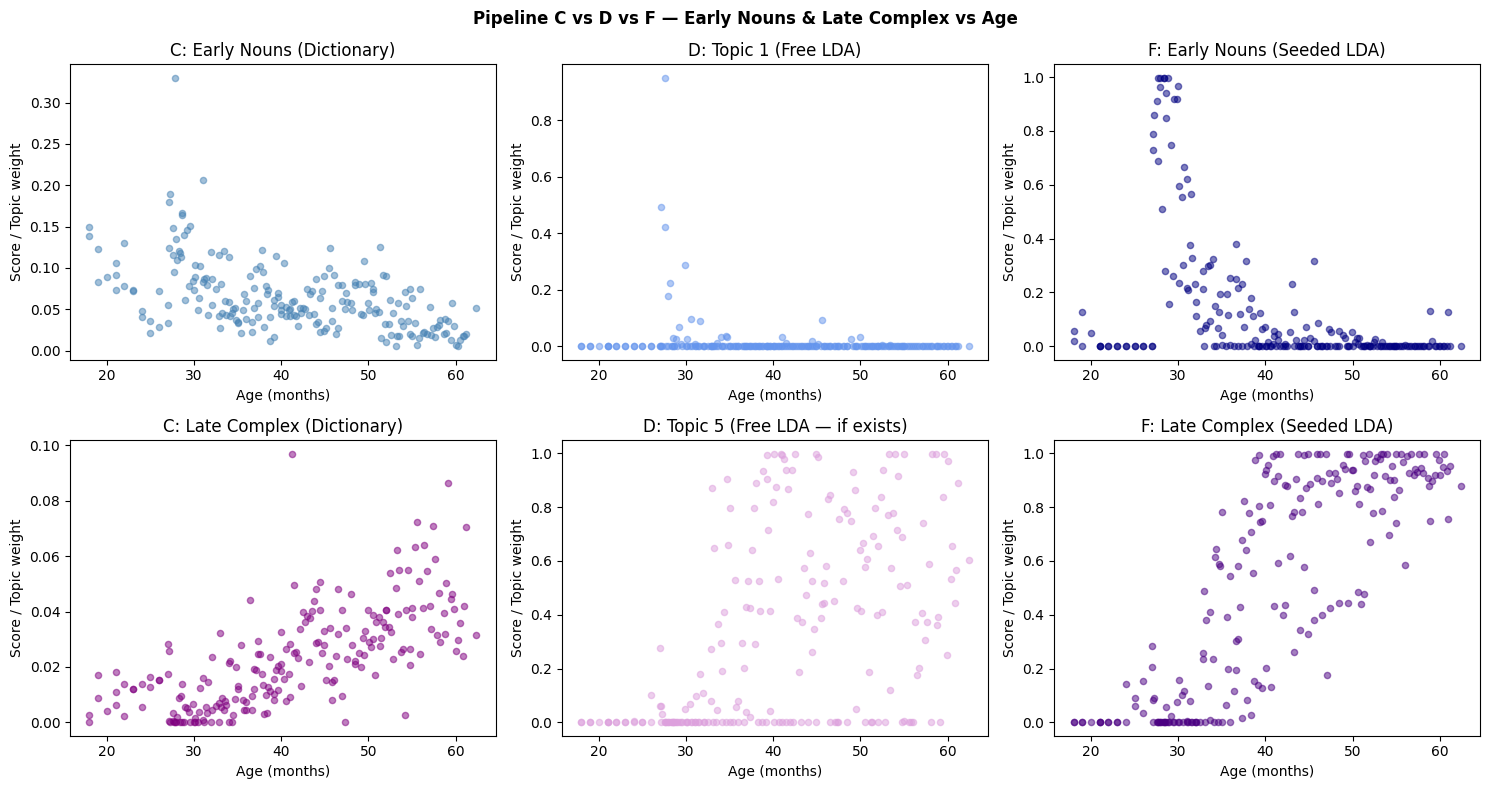

In [31]:
# Plot: how do early nouns and late complex evolve with age?
# We can compare Pipeline C (dictionary), Pipeline D (free LDA), Pipeline F (seeded LDA)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))            # 2 rows × 3 cols

# Row 1: Early Nouns comparison across methods
# Row 2: Late Complex comparison across methods

comparisons = [
    # (x_data, y_data, color, title)
    (df['age_months'], df['score_early_nouns'],      'steelblue',  'C: Early Nouns (Dictionary)'),
    (df['age_months'], topic_matrix[:, 0],           'cornflowerblue', 'D: Topic 1 (Free LDA)'),
    (df['age_months'], seeded_matrix[:, 0],          'navy',       'F: Early Nouns (Seeded LDA)'),
    (df['age_months'], df['score_late_complex'],     'purple',     'C: Late Complex (Dictionary)'),
    (df['age_months'], topic_matrix[:, 4],           'plum',       'D: Topic 5 (Free LDA — if exists)'),
    (df['age_months'], seeded_matrix[:, 4],          'indigo',     'F: Late Complex (Seeded LDA)'),
]

for ax, (x, y, color, title) in zip(axes.flatten(), comparisons):  # one plot per comparison
    ax.scatter(x, y, alpha=0.5, color=color, s=20)         # scatter: age vs score
    ax.set_xlabel('Age (months)')                          # x axis
    ax.set_ylabel('Score / Topic weight')                  # y axis
    ax.set_title(title)                                    # title

plt.suptitle('Pipeline C vs D vs F — Early Nouns & Late Complex vs Age',
             fontsize=12, fontweight='bold')               # main title
plt.tight_layout()                                         # clean layout
plt.savefig('../figures/pipeline_F_comparison.png',        # save
            dpi=150, bbox_inches='tight')
plt.show()                                                 # display

Save Pipeline F:

In [32]:
# Build Pipeline F output DataFrame
df_F = df[base_cols].copy()                                # start from metadata

for i in range(N_TOPICS_F):                               # add topic weight columns
    df_F[f'topic_{TOPIC_NAMES[i].lower().replace(" ","_")}'] = seeded_matrix[:, i]  # named columns

df_F.to_csv("../data/processed/pipeline_F_seeded_lda.csv", # save Pipeline F
            index=False)

print("Pipeline F saved → pipeline_F_seeded_lda.csv")
print(f"Shape: {df_F.shape}")                             # (214, 9)
print(df_F.head(3))                                       # preview

Pipeline F saved → pipeline_F_seeded_lda.csv
Shape: (214, 9)
  child_id  age_months   mlu       ttr  topic_early_nouns  topic_action_words  \
0     Adam       27.13  2.00  0.314286           0.727281            0.000121   
1     Adam       27.60  1.89  0.342857           0.910615            0.000110   
2     Adam       28.10  2.33  0.351429           0.510547            0.000143   

   topic_social_words  topic_descriptors  topic_late_complex  
0            0.000120           0.272357            0.000120  
1            0.000110           0.089054            0.000111  
2            0.000143           0.489026            0.000142  
